In [400]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, OneHotEncoder, FunctionTransformer
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.impute import SimpleImputer
import math

In [401]:
# 1. Load the data from the CSV file into a pandas DataFrame
# https://www.kaggle.com/c/titanic/data
df = pd.read_csv('https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv')
df.head()


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [402]:
# Check for Missing Data
missing_cols = df.isna().any()
if missing_cols.any():
    cols_with_missing = missing_cols[missing_cols].index
    for col in cols_with_missing:
        print(f"Data Missing in {col}")
else:
    print("No Missing Data in Any Column")

Data Missing in Age
Data Missing in Cabin
Data Missing in Embarked


In [403]:
target = 'Survived'
features = [col for col in df.columns if col != target and col]

X = df[features]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=42)

In [404]:
def extract_cabin_letter(X):
    """
    Extracts the first letter from the 'Cabin' column (first column of X),
    fills missing values with 'U', and reshapes for the pipeline.
    """
    # X is expected to be a DataFrame (or slice)
    cabin_series = X.iloc[:, 0]
    letters = cabin_series.str[0]
    # Reshape to a 2D array (n_samples, 1)
    return letters.values.reshape(-1, 1)

In [405]:
numeric_features = ['Age', 'Fare']
categorical_features = ['Sex']
ordinal_features = ['Pclass']
cabin_features = ['Cabin']

pclass_categories = [[1, 2, 3]]

cabin_transformer = Pipeline(steps=[
    ('get_letter', FunctionTransformer(extract_cabin_letter)),
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', drop='first'))
])
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

ordinal_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ordinal', OrdinalEncoder(categories=pclass_categories)),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', drop='first'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('ord', ordinal_transformer, ordinal_features),
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features),
        ('cabin', cabin_transformer, cabin_features)
    ],
    remainder='drop'
)

pipe = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', DecisionTreeClassifier(random_state=42))
])

pipe.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('ord', ...), ('num', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


Model Accuracy on Test Set: 0.7778


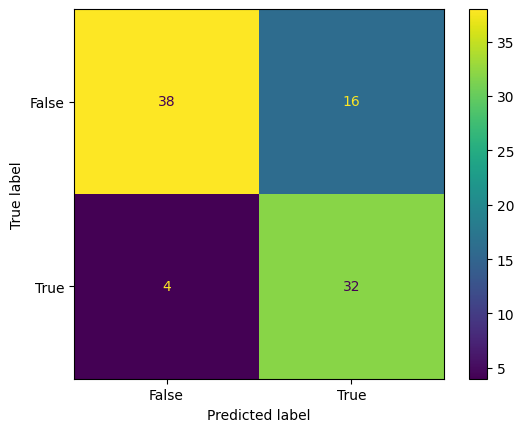

In [406]:
y_pred = pipe.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy on Test Set: {accuracy:.4f}")
class_names = y.astype(bool).unique().tolist()
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=class_names) 

In [407]:
param_grid = {
    'classifier__criterion': ['gini', 'entropy'],
    'classifier__max_depth': [3, 5, 7, 10]
}
grid_search = GridSearchCV(estimator=pipe, param_grid=param_grid, cv=5)
grid_search.fit(X_train, y_train)

/opt/homebrew/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/opt/homebrew/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/opt/homebrew/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/opt/homebrew/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/opt/homebrew/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Foun

,estimator,Pipeline(step...m_state=42))])
,param_grid,"{'classifier__criterion': ['gini', 'entropy'], 'classifier__max_depth': [3, 5, ...]}"
,scoring,None
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('ord', ...), ('num', ...), ...]"


In [408]:
print(f"\nBest parameters found by GridSearchCV: {grid_search.best_params_}")
best_model = grid_search.best_estimator_
tuned_accuracy = best_model.score(X_test, y_test)
print(f"Tuned Model Accuracy: {tuned_accuracy:.4f}")



Best parameters found by GridSearchCV: {'classifier__criterion': 'gini', 'classifier__max_depth': 7}
Tuned Model Accuracy: 0.7778


In [409]:
new_passengers = pd.DataFrame({
    'Pclass': [1, 3, 2],
    'Sex': ['female', 'male', 'female'],
    'Age': [35, 22, 5],
    'Fare': [80, 7.25, 26],
    'Embarked': ['S', 'S', 'C'],
    'SibSp': [1, 0, 1],
    'Parch': [0, 0, 2],
    'Cabin': ['A22', 'C123', 'T']
})

predictions = pipe.predict(new_passengers)
prediction_text = ['Survived' if p == 1 else 'Did not Survive' for p in predictions]

print("\n--- Example Predictions ---")
for i, (index, passenger) in enumerate(new_passengers.iterrows()):
    print(f"Prediction for passenger {i+1} ({passenger['Sex']}, age {passenger['Age']}, class {passenger['Pclass']}): {prediction_text[i]}")
print("-" * 30)



--- Example Predictions ---
Prediction for passenger 1 (female, age 35, class 1): Survived
Prediction for passenger 2 (male, age 22, class 3): Did not Survive
Prediction for passenger 3 (female, age 5, class 2): Survived
------------------------------


In [410]:
import pickle

with open('best_model - titanic.pkl', 'wb') as f:
    pickle.dump(pipe, f)